# Notebook para o desafio técnico da voxar labs: problema de classificação de tipos de estrada 

## imports

In [ ]:
# imports nescessários para a pesquisa

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 
from PIL import Image 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
import random

## Análise inicial do dataset

In [3]:
def analise_basica_dataset(data_dir, limiar_noite=60):
    dados = []
    resultados_luz = {'Dia': 0, 'Noite': 0}
    
    for split in ['train', 'test']:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir): continue
        
        for classe in os.listdir(split_dir):
            classe_dir = os.path.join(split_dir, classe)
            if not os.path.isdir(classe_dir): continue
            
            for img_name in tqdm(os.listdir(classe_dir), desc=f"Lendo {split}/{classe}"):
                img_path = os.path.join(classe_dir, img_name)
                try:
                    # PIL para resolução
                    with Image.open(img_path) as img:
                        w, h = img.size
                    
                    # OpenCV para estimativa de brilho
                    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img_gray is not None:
                        brilho_medio = np.mean(img_gray)
                        condicao = 'Noite' if brilho_medio < limiar_noite else 'Dia'
                        resultados_luz[condicao] += 1
                    else:
                        brilho_medio = None
                        condicao = None

                    dados.append({
                        'Split': split,
                        'Classe': classe,
                        'Largura': w,
                        'Altura': h,
                        'Resolucao': f"{w}x{h}",
                        'Total_Pixels': w * h,
                        'Brilho_Medio': brilho_medio,
                        'Iluminacao': condicao
                    })
                except Exception as e:
                    pass
                    
    df = pd.DataFrame(dados)
    
    # Análise para determinar a quantidade de imagens por classe no treinamento e teste
    print("\n" + "="*40)
    print("1. TOTAL DE IMAGENS POR CLASSE")
    print("="*40)
    # Mostra a contagem dividida entre treino e teste
    print(pd.crosstab(df['Classe'], df['Split'], margins=True, margins_name="Total"))
    
    # Análise para determinar as resoluções mais comuns e ter noção de como lidar com elas caso nescessário
    print("\n" + "="*40)
    print("2. TOP 5 RESOLUÇÕES MAIS COMUNS")
    print("="*40)
    print(df['Resolucao'].value_counts().head(5))
    
    # colocando algumas classes de resolução
    print("\n" + "="*40)
    print("3. CATEGORIAS DE RESOLUÇÃO")
    print("="*40)
    full_hd = len(df[df['Total_Pixels'] >= (1920 * 1080)])
    hd = len(df[(df['Total_Pixels'] >= (1280 * 720)) & (df['Total_Pixels'] < (1920 * 1080))])
    baixa_res = len(df[df['Total_Pixels'] < (1280 * 720)])
    
    print(f"Imagens >= Full HD (1080p): {full_hd}")
    print(f"Imagens HD (720p): {hd}")
    print(f"Imagens Baixa Resolução (< 720p): {baixa_res}")
    
    # tentando averiguar a quantidade de fotos a noite ou de dia utilizando a média de brilho com opencv 
    # (esse não é um método perfeito já que uma foto do asfalto novo por ser muito preto pode ter brilho semelhante ao de uma imagem a noite mesmo estando de dia, mas pode dar uma noção geral para a pesquisa)
    print("\n" + "="*40)
    print("4. ESTIMATIVA DE ILUMINAÇÃO (DIA/NOITE)")
    print("="*40)
    print("*Nota: Método heurístico baseado em brilho médio. Pode falhar em asfalto muito escuro de dia.")
    print(f"Total Dia (estimado): {resultados_luz['Dia']}")
    print(f"Total Noite (estimado): {resultados_luz['Noite']}")
    
    return df

df_metadata = analise_basica_dataset('..\dataset_processed')

<>:81: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:81: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_5172\1682289904.py:81: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_metadata = analise_basica_dataset('..\dataset_processed')
Lendo test/offroad: 100%|██████████| 50/50 [00:00<00:00, 200.76it/s]


1. TOTAL DE IMAGENS POR CLASSE
Split           test  train  Total
Classe                            
asphalt          218    655    873
belgian_blocks    32     94    126
offroad           50    151    201
Total            300    900   1200

2. TOP 5 RESOLUÇÕES MAIS COMUNS
Resolucao
1920x1080    948
768x576       76
1920x972      43
1280x576      31
1920x806      24
Name: count, dtype: int64

3. CATEGORIAS DE RESOLUÇÃO
Imagens >= Full HD (1080p): 948
Imagens HD (720p): 107
Imagens Baixa Resolução (< 720p): 145

4. ESTIMATIVA DE ILUMINAÇÃO (DIA/NOITE)
*Nota: Método heurístico baseado em brilho médio. Pode falhar em asfalto muito escuro de dia.
Total Dia (estimado): 608
Total Noite (estimado): 592


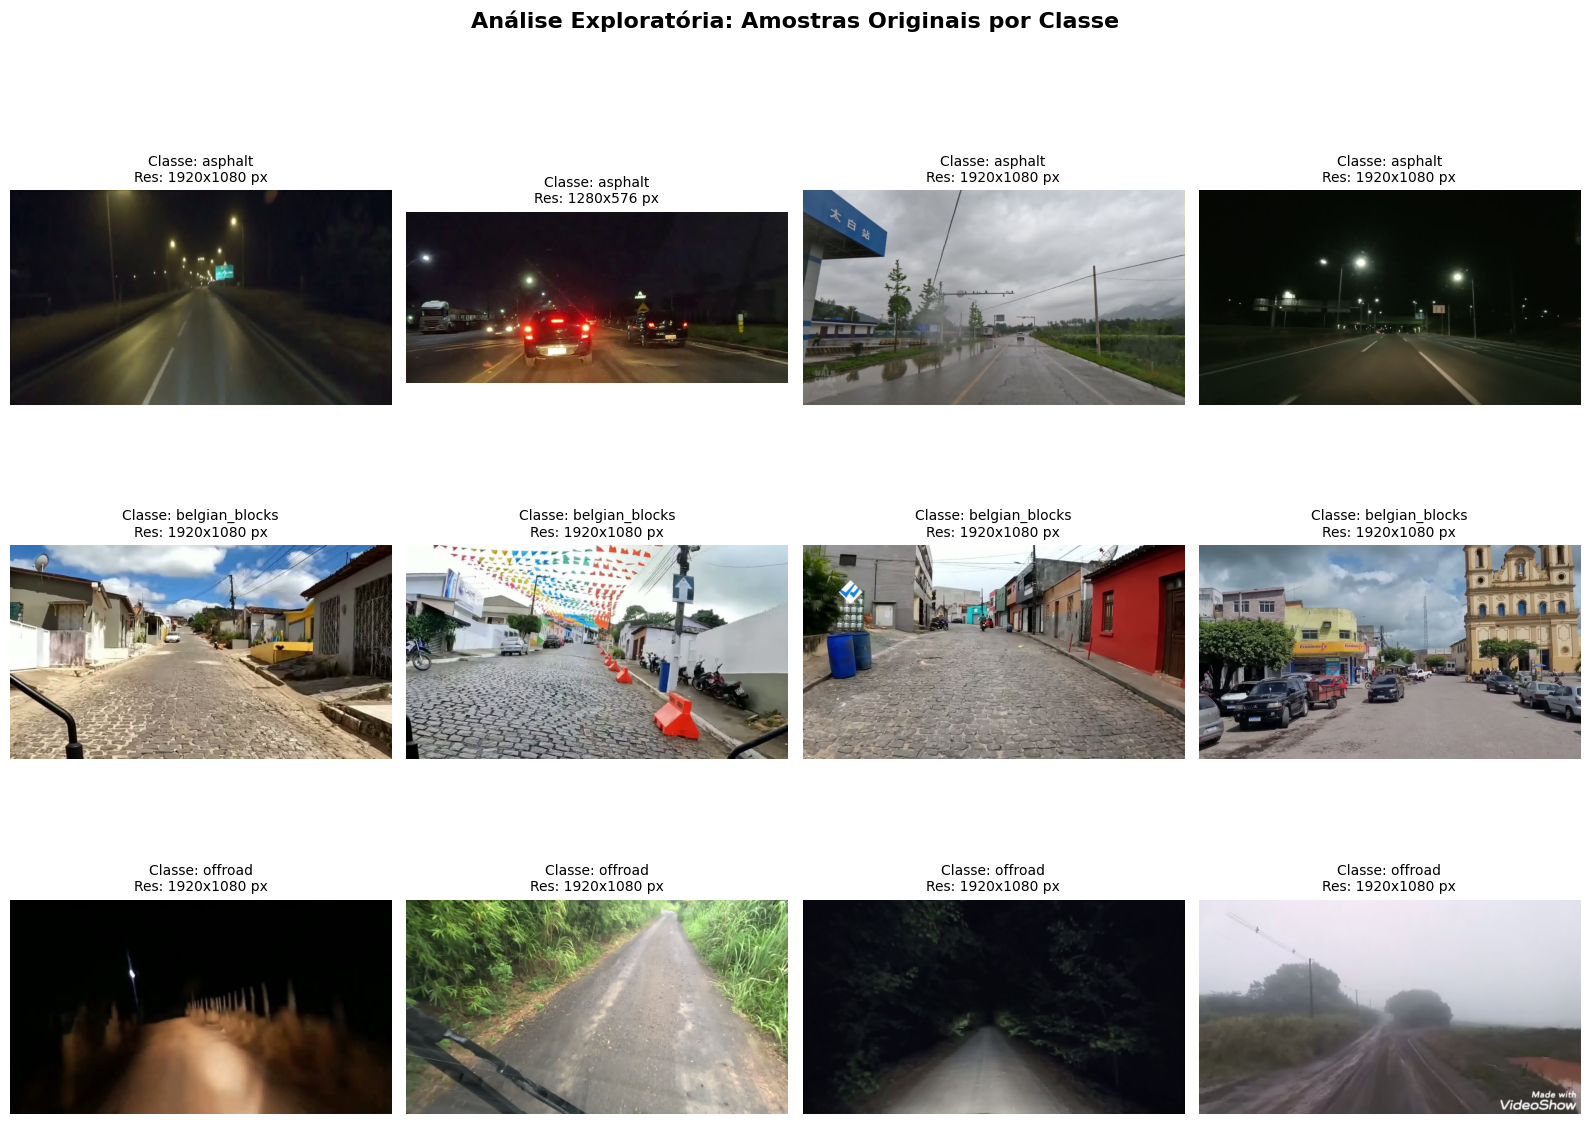

In [7]:
# Função para visualizar amostras do dataset com suas respectivas classes e resoluções
def visualizar_amostras_dataset(data_dir, amostras_por_classe=3):
    train_dir = os.path.join(data_dir, 'train')
    classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]
    
    fig, axes = plt.subplots(len(classes), amostras_por_classe, figsize=(amostras_por_classe * 4, len(classes) * 4))
    fig.suptitle('Análise Exploratória: Amostras Originais por Classe', fontsize=16, weight='bold', y=1.02)

    for i, classe in enumerate(classes):
        caminho_classe = os.path.join(train_dir, classe)
        todas_imagens = os.listdir(caminho_classe)
        
        # Sorteia imagens aleatórias para evitar pegar sempre as mesmas
        imagens_sorteadas = random.sample(todas_imagens, amostras_por_classe)

        for j, nome_img in enumerate(imagens_sorteadas):
            caminho_img = os.path.join(caminho_classe, nome_img)
            
            img = Image.open(caminho_img)
            largura, altura = img.size
            
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            
            ax.imshow(img)
            ax.axis('off')            

            ax.set_title(f"Classe: {classe}\nRes: {largura}x{altura} px", fontsize=10)

    plt.tight_layout()
    plt.show()

caminho_base_dataset = '..\\dataset_processed' 
visualizar_amostras_dataset(caminho_base_dataset, amostras_por_classe=4)

## considerações inciais sobre o problema e como sera conduzida a resolução

Entendimento do Problema

Neste desafio, o objetivo é classificar imagens de superfícies de vias em três categorias distintas: *Asphalt*, *Belgian Blocks* e *Off-road*. 

A análise exploratória inicial dos dados revela desafios significativos que vão além do simples reconhecimento de padrões. Os principais obstáculos quantificados são:

* **Desbalanceamento Severo:** A distribuição das 1.200 imagens totais é extremamente desigual. A classe *Asphalt* domina o conjunto com 873 amostras (~72%), enquanto *Off-road* possui 201 e *Belgian Blocks* é a minoria crítica com apenas 126 amostras (~10%). Essa disparidade inviabiliza o uso da acurácia global como métrica principal, pois um modelo enviesado tenderia a prever apenas a classe majoritária.
* **Condições Visuais Adversas e Ruído:** O dataset reflete o mundo real com severas restrições de visibilidade. A estimativa heurística indicou que praticamente metade do conjunto de dados (592 de 1.200 imagens) foi capturada em condições noturnas ou de baixíssima luminosidade. Essa ausência de luz natural intensifica o ruído visual dos sensores das câmeras (granulação). Somam-se a isso elementos como ofuscamento por faróis, sombras densas, sujeira ou poças d'água na pista, que atuam mascarando as texturas fundamentais que diferenciam os tipos de via.
* **Dependência Contextual:** Uma hipótese central é que o modelo pode sofrer com o "viés de vizinhança", aprendendo a classificar a via com base no ambiente ao redor em vez da superfície em si. Por exemplo, a rede pode associar erroneamente a presença de vegetação densa a *Off-road*, áreas urbanas com casas a *Belgian Blocks* ou a presença de tráfego intenso de carros a *Asphalt*.
* **Heterogeneidade de Captura:** Os metadados confirmam a variação nos dispositivos de câmera. Embora 948 imagens possuam resolução maior ou igual a Full HD (1080p), há uma parcela expressiva de formatos HD e de baixa resolução (< 720p, com 145 amostras), além de proporções de tela não padronizadas (ex: 768x576 e 1920x972). Isso introduz distorções de perspectiva (câmeras posicionadas em ângulos e alturas diferentes) e afeta a escala visual: em baixa resolução ou com desfoque de movimento, os contornos de um bloco belga perdem definição, podendo facilmente ser confundidos com asfalto deteriorado ou terreno irregular.

Devido a esse cenário de desbalanceamento e ruído, a avaliação da performance do modelo não pode se apoiar na acurácia global, sendo obrigatoriamente guiada por métricas mais rigorosas e adequadas para classes minoritárias, como o **F1-Score, Recall e a área sob a curva ROC (ROC-AUC)**.

**Experimentos a serem realizados**

Para solucionar o problema respeitando o foco em soluções bem justificadas em vez de arquiteturas complexas, foi definida uma abordagem progressiva baseada em *Transfer Learning* utilizando a rede pré-treinada **ResNet18**.

A investigação seguirá uma solução Baseline seguida de **três experimentos** incrementais:

* **Solução Baseline:** Implementação direta da ResNet18 modificando apenas a camada de classificação final. Os dados passarão apenas por redimensionamento e normalização padrão, estabelecendo um ponto de partida para as métricas.

* **Experimento 1: Data Augmentation**
    * *Hipótese:* A aplicação de transformações aleatórias reduzirá o *overfitting* e ajudará o modelo a generalizar melhor perante a heterogeneidade das imagens, forçando-o a focar mais na textura da via e não no cenário (casas, matas ou carros)..
    * *Abordagem:* Inclusão de um *pipeline* de *Data Augmentation* no conjunto de treino utilizando técnicas nativas do `torchvision` (como *Random Crop*, rotações, espelhamento horizontal, *ColorJitter* para simular variações de iluminação diurna/noturna, *Random Erasing* e *Random Perspective*) combinadas com técnicas customizadas via `OpenCV` (como aplicação de *blur*/desfoque, adição de ruído, simulação de chuva e CLAHE para correção avançada de sombras).

* **Experimento 2: Tratamento do Desbalanceamento**
    * *Hipótese:* O modelo, mesmo com *Data Augmentation*, tende a ignorar a classe minoritária. Penalizar erros ou balancear a amostragem forçará a rede a focar nas amostras e padrões mais difíceis.
    * *Abordagem:* Aplicação das melhores transformações do Experimento 1, combinadas com técnicas avançadas focadas em desbalanceamento. Serão testadas diferentes estratégias e suas combinações, incluindo o uso de pesos por classe (`class_weights`), amostragem balanceada (`WeightedRandomSampler` no *DataLoader*) e a função de custo *Focal Loss*. A investigação avaliará essas técnicas de forma combinada (ex: *Focal Loss* + `class_weights`, ou *Focal Loss* + `WeightedRandomSampler`) para otimizar a estabilidade e o aprendizado das classes com menos imagens.

* **Experimento 3: Exploração de Complexidade**
    * *Hipótese:* Verificar se os padrões complexos (como a diferença sutil entre blocos belgas e asfalto deteriorado) exigem uma rede com maior capacidade de extração de características do que a ResNet18.
    * *Abordagem:* Pegar a melhor configuração de dados dos experimentos anteriores e treinar uma **ResNet50**. O objetivo é analisar criticamente se o aumento na complexidade do modelo se traduz em um ganho real de *performance* ou se apenas acelera o *overfitting* devido à escassez de dados.

**Estratégia de Treinamento e Fine-Tuning**

Com exceção do modelo *Baseline* (onde apenas a camada linear final será ajustada de forma direta), as redes dos experimentos experimentais serão treinadas seguindo uma metodologia estruturada de *Fine-Tuning* para maximizar a transferência de aprendizado:

* **Preparação e Adaptação:** Carregamento da arquitetura ResNet pré-treinada no ImageNet, aplicando estritamente os parâmetros de normalização e pré-processamento originais exigidos pela rede.
* **Reconstrução da Cabeça de Classificação:** Substituição da camada final por uma nova estrutura adaptada ao problema, utilizando *Global Average Pooling* seguido de camadas densas para afunilar a predição nas 3 categorias (Asphalt, Belgian Blocks, Off-road).
* **Treinamento em Duas Etapas:**
    * *Fase 1:* Congelamento completo da base convolucional para treinar exclusivamente a nova cabeça de classificação. Isso evita que gradientes aleatórios iniciais desestabilizem os pesos já aprendidos.
    * *Fase 2 (Fine-tuning):* Descongelamento gradual das camadas convolucionais superiores, reiniciando o treinamento com um (*learning rate*) significativamente reduzida. O objetivo é permitir que os filtros de alto nível da rede se adaptem às texturas específicas e aos ruídos visuais dos nossos dados.

## Carregando os data sets e separando os conjuntos de treino, validação e test para o baseline e experimentos 1 e 2 que serão realizados

criando caminho dos dados

In [ ]:
# Criando os caminho para os dados
data_dir = '..\\dataset_processed'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

Criando os dados para o modelo baseline onde será apenas aplicada a normalização e escalonamento esperado para a resnet18 do pytorch


In [ ]:
# Criando as transformações nescessárias usadas nas resnets e imagenet do pytorch que serão aplicadas ao conjunto de treinamento e teste para serem usado no modelo baseline
baseline_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# Separando o conjunto de treino e validação
full_train_dataset_augmented_baseline = datasets.ImageFolder(train_dir, transform=baseline_transforms['train'])
full_train_dataset_clean_baseline = datasets.ImageFolder(train_dir, transform=baseline_transforms['test'])

targets = full_train_dataset_augmented_baseline.targets
indices = np.arange(len(targets))

# Dividimos os índices: 80% para treino e 20% para validação
# O 'stratify=targets' garante que a proporção de Belgian Blocks não se perca no sorteio
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=targets, 
    random_state=42
)

image_datasets_baseline = {
    'train': Subset(full_train_dataset_augmented_baseline, train_idx),
    'val': Subset(full_train_dataset_clean_baseline, val_idx),
    'test': datasets.ImageFolder(test_dir, transform=baseline_transforms['test'])
}

dataloaders_baseline = {
    'train': DataLoader(image_datasets_baseline['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets_baseline['val'], batch_size=32, shuffle=False, num_workers=2),
    'test': DataLoader(image_datasets_baseline['test'], batch_size=32, shuffle=False, num_workers=2)
}

Criando os dados para os experiemtos **1** e **2**

In [ ]:
"""
Criando os dados para o experiento 1:
Aqui vamos criar uma classe para as transformações que vão ocorrer via opencv, 
e para todas as transformações não importando a biblioteca colocaremos uma probabilidade para cada transformação ocorrer,
assim teremos uma variedade de imagens para o modelo aprender e não ficar viciado em um tipo de transformação,
além de evitar imagens muito distorcidas que podem atrapalhar o aprendizado do modelo.
Para escolher essas probabilidades eu usei a intuição de que as transformações mais simples como rotação e flip tem uma probabilidade maior de ocorrer do que as transformações mais complexas como distorção e adição de ruído.
"""

# classe para as transformações usando opencv
class OpenCVTransforms:
    """
    O parâmetro p (0.0 a 1.0) define a chance de cada transformação acontecer.
    """
    def __init__(self, p_clahe=0.25, p_blur=0.15, p_noise=0.15, p_rain=0.1):
        self.p_clahe = p_clahe
        self.p_blur = p_blur
        self.p_noise = p_noise
        self.p_rain = p_rain

    def __call__(self, img):
        # Converte a imagem para array numpy
        img_np = np.array(img)

        # CLAHE (Correção de Sombras)
        if random.random() < self.p_clahe:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l_clahe = clahe.apply(l)
            lab_clahe = cv2.merge((l_clahe, a, b))
            img_np = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

        # 2. Blur
        if random.random() < self.p_blur:
            ksize = random.choice([2, 5])
            img_np = cv2.GaussianBlur(img_np, (ksize, ksize), 0)

        # 3. Adição de Ruído
        if random.random() < self.p_noise:
            row, col, ch = img_np.shape
            gauss = np.random.normal(0, 15, (row, col, ch)).astype(np.float32)
            img_np = np.clip(img_np.astype(np.float32) + gauss, 0, 255).astype(np.uint8)

        # 4. Simulação de Chuva Leve
        if random.random() < self.p_rain:
            rain_drops = random.randint(100, 300) 
            for _ in range(rain_drops):
                x = random.randint(0, img_np.shape[1] - 1)
                y = random.randint(0, img_np.shape[0] - 15)
                cv2.line(img_np, (x, y), (x + random.randint(-1, 2), y + random.randint(5, 15)), (200, 200, 200), 1)

        # Retorna para o formato do pytorch
        return Image.fromarray(img_np)

# Realizando as transformações para o experimento 1
exp1_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
 
        OpenCVTransforms(),
        
        transforms.ToTensor(),
    
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), value='random'),

        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    
    # teste igual baseline para avaliar o impacto das transformações do experimento 1
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


# Separando o conjunto de treino e validação
full_train_dataset_augmented_exp1 = datasets.ImageFolder(train_dir, transform=exp1_transforms['train'])
full_train_dataset_clean_exp1 = datasets.ImageFolder(train_dir, transform=exp1_transforms['test'])

targets = full_train_dataset_augmented_exp1.targets
indices = np.arange(len(targets))

# Dividimos os índices: 80% para treino e 20% para validação
# O 'stratify=targets' garante que a proporção de Belgian Blocks não se perca no sorteio
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=targets, 
    random_state=42
)

image_datasets_exp1 = {
    'train': Subset(full_train_dataset_augmented_exp1, train_idx),
    'val': Subset(full_train_dataset_clean_exp1, val_idx),
    'test': datasets.ImageFolder(test_dir, transform=exp1_transforms['test'])
}

dataloaders_exp1 = {
    'train': DataLoader(image_datasets_exp1['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets_exp1['val'], batch_size=32, shuffle=False, num_workers=2),
    'test': DataLoader(image_datasets_exp1['test'], batch_size=32, shuffle=False, num_workers=2)
}

In [ ]:
"""
Criando os dados para o Experimento 2:
Herdamos as melhores transformações do Experimento 1, mas alteramos a amostragem.
Aqui calculamos os pesos das classes baseados na sua frequência.
Isso servirá tanto para o WeightedRandomSampler (que faz o oversampling das classes minoritárias dinamicamente)
quanto para aplicar pesos diretamente na Função de Custo.
"""

# Reutilizamos as transformações e recriamos os datasets
exp2_transforms = exp1_transforms 

image_datasets_exp2 = {
    'train': Subset(full_train_dataset_augmented_exp1, train_idx),
    'val': Subset(full_train_dataset_clean_exp1, val_idx),
    'test': datasets.ImageFolder(test_dir, transform=exp2_transforms['test'])
}

#  Cálculos para o Tratamento de Desbalanceamento

train_dataset = image_datasets_exp2['train']
targets = [train_dataset.dataset.targets[i] for i in train_dataset.indices] # Pega o rótulo (0, 1 ou 2) de todas as imagens

class_counts = np.bincount(targets)
print(f"Distribuição original das classes: {class_counts}")

# Pesos para o Sampler (Inverso da frequência)
class_weights_sampler = 1.0 / class_counts

# Cria uma lista dando um peso específico para cada imagem individual do dataset
sample_weights = [class_weights_sampler[label] for label in targets]

# Cria o amostrador balanceado com replacement=True
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

# Usamos o sklearn para calcular pesos balanceados para usar com CrossEntropy ou Focal Loss
class_weights_loss = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(targets), 
    y=targets
)

# Converte para Tensor do PyTorch para usar no loop de treinamento
class_weights_loss_tensor = torch.tensor(class_weights_loss, dtype=torch.float)
print(f"Pesos calculados para a Loss: {class_weights_loss_tensor}")


dataloaders_exp2 = {
    'train': DataLoader(image_datasets_exp2['train'], batch_size=32, sampler=sampler, num_workers=2), # usamos o sampler para o treinamento em substituição ao shuffle
    'val': DataLoader(image_datasets_exp2['val'], batch_size=32, shuffle=False, num_workers=2),
    'test': DataLoader(image_datasets_exp2['test'], batch_size=32, shuffle=False, num_workers=2)
}

## Implementação do baseline

Definindo o device onde o código ira rodar (cpu ou gpu)

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

Treinando no dispositivo: cpu


Criando o modelo resnet18 para baseline

In [ ]:
print("=== INICIANDO TREINAMENTO: BASELINE ===")

# 1. Instancia o modelo na versão simples (sem dropout na cabeça)
modelo_baseline = criar_modelo_resnet(num_classes=3, modo_experimento=False)

# 2. Prepara para treinar APENAS a última camada (congelando todo o resto)
modelo_baseline = preparar_fase1(modelo_baseline)

# 3. Define a Função de Custo padrão e o Otimizador
criterion_baseline = nn.CrossEntropyLoss()
optimizer_baseline = torch.optim.Adam(modelo_baseline.fc.parameters(), lr=1e-3)

# 4. Inicia o loop de treinamento
modelo_baseline, hist_baseline = treinar_modelo(
    modelo_baseline, 
    dataloaders_baseline, # DataLoader sem distorções
    criterion_baseline, 
    optimizer_baseline, 
    num_epochs=15, 
    device=device
)